# 🌊 Predicting Lithologies for the Ocean Drilling Program

In this assessment, you are the **boss of your own AI consulting company**: ***<span style="color:teal">MSC-AI Consulting</span>***. Your goal is to listen to the client’s brief and implement their request to the best of your abilities.

You know that for each bid (part of this assessment), there are other, competing AI consulting companies. Keep your answers secure and aim to deliver a solution that outperforms the competition, convincing the client to score you the highest.

## 🏢 Client Overview

Your client is the **Integrated Ocean Drilling Program** (IODP), a respected research institution dedicated to drilling the seafloor to better understand Earth’s dynamic history and past climates. IODP collects two main types of data:

1. **Cores**: Physical samples of rock extracted from the seafloor, used for precise geological analysis. These samples are costly and challenging to obtain. Learn more about cores [here](https://www.ga.gov.au/scientific-topics/marine/survey-techniques/sedimentary-coring-drilling).
  
2. **Downhole (wireline) logs**: Data collected from instruments lowered into drill holes by researchers. Drill holes can extend several kilometers below the seafloor, with depth represented by `Depth_WMSF` (Water Meters Below Seafloor). Downhole logs record continuous measurements of rock properties, such as natural gamma radiation (`HCGR`), potassium (`HFK`), thorium (`HTHO`), uranium (`HURA`), resistivity at various penetration levels (`IDPH` and `IMPH`), and neutron porosity (`SFLU`). These measurements help to **reconstruct lithology** (rock types). Further details on well logging can be found [here](https://en.wikipedia.org/wiki/Well_logging).

### New Data Innovation
IODP has introduced an experimental new downhole log feature called `munsell_color`. They believe this tool, combined with traditional logs, may improve lithology classification. You are the first to test it in this context.

## ⛴️ Your Task

You have access to two datasets:

- **Training and Testing Data**: Found in `data/lithology.csv`, this contains labeled data from a single well, from 0 to 450 MWSF.
  
- **Prediction Data**: Found in `data/new_samples.csv`, this contains data from 450 to 700 MWSF in the same well but lacks lithology labels. Your task is to **predict lithology for this interval** using the provided wireline log data.

The illustration below represents this scenario:

![Well Illustration](../Excercise_data/previous_assessments/well.jpg)

### Project Requirements

IODP requests that you train an optimal model to classify lithology based on the log data. They provided specific requirements:

* 🪸 **Feature Selection**: You can preprocess and select features as you see fit, but **include `munsell_color`** in your data pipeline as this feature is crucial for the client.
  
* 🪸 **Model Selection**: Use any **parametric model** from `sklearn`, such as `LogisticRegression`, `SVC(kernel="linear")`, or `MLPClassifier`. You can confirm a model’s parametric nature by calling the `.coef_` method after fitting it. If it throws an error, the model is not parametric and will disqualify you. **Ensemble methods are not allowed**.
  
* 🪸 **Pipeline Requirement**: Construct an entire workflow within a `pipeline` object that:
    1. Accepts raw data as input and produces predictions.
    2. Uses a parametric estimator as the last step in the pipeline (the last component must be the estimator).
  
* 🪸 **Performance Metrics**: IODP will evaluate your model based on:
    - The **F1 macro-averaging score** on unseen data, compared to the score on the test set. A smaller difference is better, meaning **minimal overfitting**.
    - The **ratio of the F1 macro score on unseen data to the number of model coefficients**. IODP favors models with **higher F1 scores** and **fewer coefficients** to ensure simplicity.
  
* 🪸 **Random State**: Set `random_state=42` for any models requiring a random state to ensure fairness.


# Run the cell below first

This will help automatically reload your class when you make changes to it in **Part C**.

In [1]:
# Rob  Platt will go through this on Thurseday 14th  November in a 9 - 11 am


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
# Load the data:

df = pd.read_csv('../Excercise_data/previous_assessments/log_data.csv') # This is your EDA (Part A) and training data Parts B 

new_samples = pd.read_csv('../Excercise_data/previous_assessments/new_data.csv') # This is the file you need to predict in parts B 

In [4]:
df.head()

,DEPTH_WMSF,HCGR,HFK,HTHO,HURA,IDPH,IMPH,SFLU,lithology,munsel_color
0,0.0724,5.8481,0.0959,1.3131,-0.1712,1950.0000,1765.0116,0.0915,Sandy Mud,5R 4 10
1,0.0736,0.5881,0.0116,0.1206,0.0077,46.6488,124.4472,1.5966,Sandy Mud,10PB 0.2 18
2,0.0880,1.9945,0.0354,0.4317,0.0501,1950.0000,1950.0000,0.1589,Interbedded sand and mud,2.5YR 8 10
3,0.0920,22.4306,0.6522,3.3707,0.0916,1950.0000,1950.0000,9700.0000,Sandy Mud,10PB 0.2 18
4,0.2248,7.6691,0.1369,1.6566,-0.2301,1950.0000,1765.0116,0.0915,Sandy Mud,10PB 0.2 18


In [5]:
# Create as many cell as you need - keep your notebook clean
df.duplicated().sum()

np.int64(551)

In [6]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = df.drop(columns="lithology")
y = df["lithology"]

le = LabelEncoder()
y = pd.DataFrame(le.fit_transform(y), index=y.index)



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [8]:
y.value_counts()

0
3    4933
2    2003
0    1846
4    1369
1     929
Name: count, dtype: int64

In [9]:
import numpy as np
num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.columns.difference(num_cols)

In [10]:
print(f"Numeric Columns: {num_cols}")
print(f"Categoric Columns: {cat_cols}")

Numeric Columns: Index(['DEPTH_WMSF', 'HCGR', 'HFK', 'HTHO', 'HURA', 'IDPH', 'IMPH', 'SFLU'], dtype='object')
Categoric Columns: Index(['munsel_color'], dtype='object')


In [11]:
X_train.isna().mean().sum()

np.float64(0.0)

In [12]:
corr_matrix = X_train[num_cols].corr()
corr_matrix

,DEPTH_WMSF,HCGR,HFK,HTHO,HURA,IDPH,IMPH,SFLU
DEPTH_WMSF,1.000000,0.479507,0.415510,0.534358,0.594374,-0.558140,-0.604016,-0.292485
HCGR,0.479507,1.000000,0.983513,0.977623,0.531393,-0.615022,-0.673955,-0.312909
HFK,0.415510,0.983513,1.000000,0.923463,0.519835,-0.583237,-0.641731,-0.295325
HTHO,0.534358,0.977623,0.923463,1.000000,0.523008,-0.626529,-0.683545,-0.320451
HURA,0.594374,0.531393,0.519835,0.523008,1.000000,-0.489179,-0.531500,-0.238623
IDPH,-0.558140,-0.615022,-0.583237,-0.626529,-0.489179,1.000000,0.901747,0.535440
IMPH,-0.604016,-0.673955,-0.641731,-0.683545,-0.531500,0.901747,1.000000,0.505406
SFLU,-0.292485,-0.312909,-0.295325,-0.320451,-0.238623,0.535440,0.505406,1.000000


In [13]:
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [column for column in upper_tri.columns if any(np.abs(upper_tri[column]) > 0.75)]

# update the numerical columns
num_cols = num_cols.difference(high_corr_pairs)
X_train = X_train.drop(columns=high_corr_pairs)

In [14]:
X_train[num_cols].corr()

,DEPTH_WMSF,HCGR,HURA,IDPH,SFLU
DEPTH_WMSF,1.000000,0.479507,0.594374,-0.558140,-0.292485
HCGR,0.479507,1.000000,0.531393,-0.615022,-0.312909
HURA,0.594374,0.531393,1.000000,-0.489179,-0.238623
IDPH,-0.558140,-0.615022,-0.489179,1.000000,0.535440
SFLU,-0.292485,-0.312909,-0.238623,0.535440,1.000000


<Axes: >

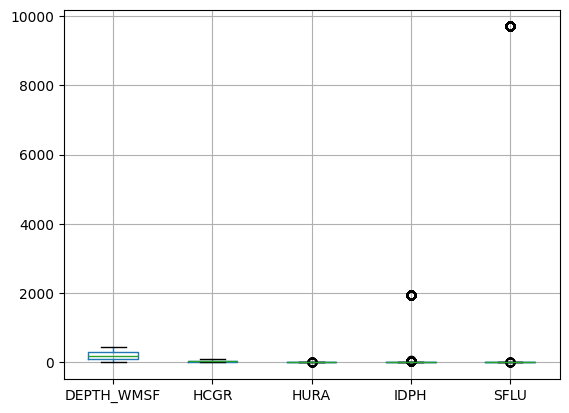

In [15]:
X_train[num_cols].boxplot()

In [16]:
def winsorise(feat, lb_pct=0.02, ub_pct=0.98):
    feat = feat.copy()
    lb = np.percentile(feat, lb_pct*100)
    ub = np.percentile(feat, ub_pct*100)

    mask_lb = feat < lb
    mask_ub = feat > ub
    
    feat[mask_lb] = lb
    feat[mask_ub] = ub

    return feat

num_out_cols = ["IDPH", "SFLU"]
for col in num_out_cols:
    X_train[col] = winsorise(X_train[col])

In [17]:
X_train[num_cols].boxplot()

<Axes: >

In [18]:
X_train[num_cols].hist()

array([[<Axes: title={'center': 'DEPTH_WMSF'}>,
        <Axes: title={'center': 'HCGR'}>],
       [<Axes: title={'center': 'HURA'}>,
        <Axes: title={'center': 'IDPH'}>],
       [<Axes: title={'center': 'SFLU'}>, <Axes: >]], dtype=object)

In [19]:
X_train[num_cols].min()

DEPTH_WMSF    0.072400
HCGR          0.029500
HURA         -0.510500
IDPH          1.001026
SFLU          0.091500
dtype: float64

In [20]:
len(X_train[cat_cols].value_counts().index)

40

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, RobustScaler, FunctionTransformer, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.feature_selection import SelectFromModel

log_transf_cols = ["IDPH", "SFLU"]
rob_cols = ["HCGR", "HURA"]
minmax_cols = ["DEPTH_WMSF"]

log_fn = FunctionTransformer(lambda x: np.log1p(x), feature_names_out="one-to-one")
clip_negatives = FunctionTransformer(lambda x: np.clip(x, a_min=0, a_max=None), feature_names_out="one-to-one")


preproc_num = ColumnTransformer(
    transformers=[
        ("neg_vals", clip_negatives, num_cols),
        ("log", log_fn, log_transf_cols),
        ("rob", RobustScaler(), rob_cols),
        ("minmax", MinMaxScaler(), minmax_cols)
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", preproc_num, num_cols),
        ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop="first"), cat_cols)
    ]
)

ovr = OneVsRestClassifier(
            LogisticRegression(penalty='l1', solver='saga', C=0.05, max_iter=5000, tol=1e-3, random_state=42),
            n_jobs=-1
        )

pipe = Pipeline(
    steps=[
        ("preproc", preprocessor),
        ("clf", ovr)
    ]
)



In [22]:
from sklearn.inspection import permutation_importance
import numpy as np

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, stratify=y_train, test_size=0.2, random_state=42)

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop="first")

X_train_processed_arr = preprocessor.fit_transform(X_tr)
X_train_processed = pd.DataFrame(X_train_processed_arr, index=X_tr.index, columns=preprocessor.get_feature_names_out())

pipe.fit(X_tr, y_tr)

X_val_proc = preprocessor.transform(X_val)

clf = pipe.named_steps["clf"] 

r = permutation_importance(clf, X_val_proc, y_val,
                           n_repeats=10, scoring="f1_macro",
                           random_state=42, n_jobs=-1)

importance_df = pd.DataFrame(
    np.vstack((X_train_processed.columns, r.importances_mean)).T, 
    columns=['feature','score decrease']
)

importance_df.sort_values(by="score decrease", ascending = False).head(12)

,feature,score decrease
3,num__neg_vals__IDPH,0.144679
0,num__neg_vals__DEPTH_WMSF,0.085055
1,num__neg_vals__HCGR,0.04787
10,cat__munsel_color_10B 8 12,0.000697
26,cat__munsel_color_2.5G 1 8,0.000639
6,num__log__SFLU,0.000639
7,num__rob__HCGR,0.000559
17,cat__munsel_color_10PB 0.2 18,0.000239
2,num__neg_vals__HURA,0.000145
36,cat__munsel_color_5P 3 6,0.00008


In [23]:
K = 11
topK = importance_df.sort_values(by="score decrease", ascending = False).head(11)
keep_features = topK["feature"].tolist()
remove_feat = X_train_processed.columns.difference(keep_features)
X_train_proc = pd.DataFrame(preprocessor.fit_transform(X_train), index=X_train.index, columns=preprocessor.get_feature_names_out())
X_train_proc = X_train_proc.drop(columns=remove_feat)

In [24]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(clf, X_train_proc, y_train, cv=5, scoring='f1_macro', n_jobs=-1)

In [25]:
scores.mean()/11

np.float64(0.05010151724974254)

### ☄️ GOOD LUCK!